# Dask-native OD connectivity

Demonstrates a fully lazy pipeline from a chunked dataset to OD counts:
open → slice → label → xarray Dataset → dask DataFrame → groupby.
No intermediate materialisation until the final `.compute()`.

## Imports

In [1]:
from importlib.resources import files
import numpy as np
import pandas as pd
import xarray as xr
import dask.array as da
import geopandas as gpd
from shapely.geometry import Polygon
from matplotlib import pyplot as plt
from hextraj import HexProj
from hextraj.hex_id import INVALID_HEX_ID

## Load data

We open the bundled dataset with `chunks={"traj": 500}` to produce a
dask-backed xarray Dataset — the same pattern as opening a zarr store.
Chunking along `traj` (not `obs`) means each chunk contains full trajectories,
so slicing to `obs=0` and `obs=-1` later costs nothing extra.

In [2]:
path = files("hextraj").joinpath("data/trajs/nwshelf.nc")
ds = xr.open_dataset(path, chunks={"traj": 500})
ds

/var/folders/w1/m9mm9h9167z_gcfzfffr0rgsh6j6kj/T/ipykernel_41200/3918197152.py:2: UserWarning: The specified chunks separate the stored chunks along dimension "traj" starting at index 500. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(path, chunks={"traj": 500})


<xarray.Dataset> Size: 4MB
Dimensions:      (traj: 5000, obs: 20)
Dimensions without coordinates: traj, obs
Data variables:
    time         (traj, obs) datetime64[ns] 800kB dask.array<chunksize=(500, 20), meta=np.ndarray>
    trajectory   (traj, obs) float64 800kB dask.array<chunksize=(500, 20), meta=np.ndarray>
    lon          (traj, obs) float32 400kB dask.array<chunksize=(500, 20), meta=np.ndarray>
    lat          (traj, obs) float32 400kB dask.array<chunksize=(500, 20), meta=np.ndarray>
    z            (traj, obs) float32 400kB dask.array<chunksize=(500, 20), meta=np.ndarray>
    temperature  (traj, obs) float32 400kB dask.array<chunksize=(500, 20), meta=np.ndarray>
    salinity     (traj, obs) float32 400kB dask.array<chunksize=(500, 20), meta=np.ndarray>
    land         (traj, obs) float32 400kB dask.array<chunksize=(500, 20), meta=np.ndarray>
Attributes:
    feature_type:           trajectory
    Conventions:            CF-1.6/CF-1.7
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_version:        2.3.1
    parcels_mesh:           spherical

## Slice start and end positions

Only the first and last observation are needed for start-to-end connectivity.
With traj-chunked data, `isel(obs=...)` is a cheap numpy slice within each
chunk — the middle 998 steps are never read.

In [3]:
lon_start = ds.lon.isel(obs=0)
lat_start = ds.lat.isel(obs=0)
lon_end   = ds.lon.isel(obs=-1)
lat_end   = ds.lat.isel(obs=-1)

## Set up HexProj

In [4]:
lon_origin = float((ds.lon.min() + ds.lon.max()) / 2)
lat_origin = float((ds.lat.min() + ds.lat.max()) / 2)
hp = HexProj(lon_origin=lon_origin, lat_origin=lat_origin, hex_size_meters=20_000)
hp

HexProj(projection_name='laea', lon_origin=-2.9847207069396973, lat_origin=54.37133026123047, hex_size_meters=20000, hex_orientation='flat', )

## Label with `map_blocks`

`hp.label()` materialises at the pyproj boundary, so it cannot accept a dask
array directly. `da.map_blocks` calls it chunk-by-chunk, keeping the result
lazy. No compute happens here.

In [5]:
from_ids = da.map_blocks(hp.label, lon_start.data, lat_start.data, dtype=np.int64)
to_ids   = da.map_blocks(hp.label, lon_end.data,   lat_end.data,   dtype=np.int64)

## Wire to a dask DataFrame

Reassemble the two label arrays into an xarray Dataset, then call
`.to_dask_dataframe()`. This maps directly onto the existing dask graph —
no new chunks are introduced, no data is moved.

In [6]:
connectivity = xr.Dataset({
    "from_id": xr.DataArray(from_ids, dims=["traj"]),
    "to_id":   xr.DataArray(to_ids,   dims=["traj"]),
})
ddf = connectivity.to_dask_dataframe()
ddf

,traj,from_id,to_id
npartitions=10,,,
0,int64,int64,int64
500,...,...,...
...,...,...,...
4500,...,...,...
4999,...,...,...


## OD counts

Filter invalid IDs (beached or exited trajectories), then groupby.
Dask aggregates per-chunk first, then merges — peak memory is proportional
to chunk size, not total trajectory count. The single `.compute()` triggers
the entire pipeline: zarr reads, labelling, and aggregation.

In [7]:
ddf = ddf[(ddf.from_id != INVALID_HEX_ID) & (ddf.to_id != INVALID_HEX_ID)]
od_counts = ddf.groupby(["from_id", "to_id"]).size().compute()
od_counts.name = "count"
print(f"{len(od_counts)} unique OD pairs, max count {od_counts.max()}")
od_counts.head()

3907 unique OD pairs, max count 5


/Users/wrath/src/github.com/willirath/hextraj/src/hextraj/redblobhex_array.py:98: RuntimeWarning: invalid value encountered in cast
  qi = np.round(hex.q).astype(int)
/Users/wrath/src/github.com/willirath/hextraj/src/hextraj/redblobhex_array.py:99: RuntimeWarning: invalid value encountered in cast
  ri = np.round(hex.r).astype(int)
/Users/wrath/src/github.com/willirath/hextraj/src/hextraj/redblobhex_array.py:100: RuntimeWarning: invalid value encountered in cast
  si = np.round(hex.s).astype(int)
/Users/wrath/src/github.com/willirath/hextraj/src/hextraj/redblobhex_array.py:98: RuntimeWarning: invalid value encountered in cast
  qi = np.round(hex.q).astype(int)
/Users/wrath/src/github.com/willirath/hextraj/src/hextraj/redblobhex_array.py:99: RuntimeWarning: invalid value encountered in cast
  ri = np.round(hex.r).astype(int)
/Users/wrath/src/github.com/willirath/hextraj/src/hextraj/redblobhex_array.py:100: RuntimeWarning: invalid value encountered in cast
  si = np.round(hex.s).astype(i

from_id  to_id
2        4        1
11       15       1
13       15       2
55       156      2
66       45       2
Name: count, dtype: int64

## Visualise

OD edges overlaid on the hex region. Edge width scales with trajectory count.

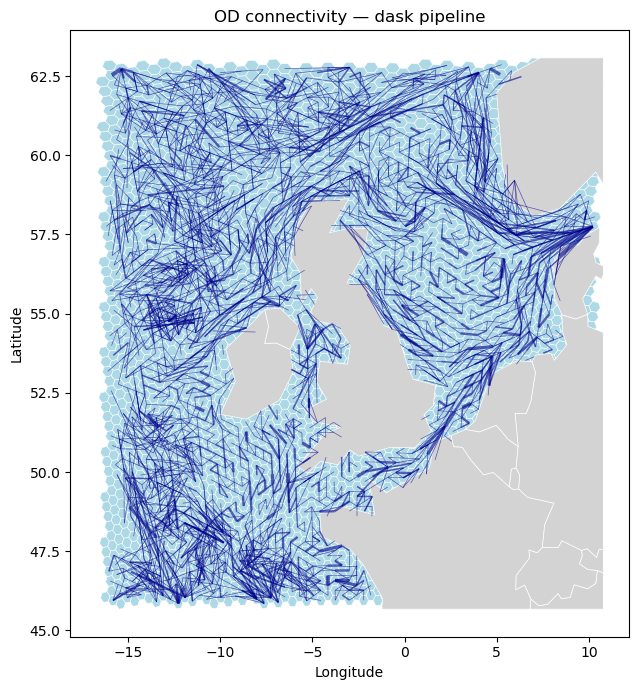

In [8]:
region_polygon = Polygon([
    (ds.lon.min(), ds.lat.min()),
    (ds.lon.max(), ds.lat.min()),
    (ds.lon.max(), ds.lat.max()),
    (ds.lon.min(), ds.lat.max()),
    (ds.lon.min(), ds.lat.min()),
])
region_gdf = hp.to_geodataframe(hp.region_of_hexes(region_polygon))

od_gdf = hp.edges_geodataframe(
    od_counts.index.get_level_values("from_id"),
    od_counts.index.get_level_values("to_id"),
    weight=od_counts.values,
)

world = gpd.read_file(
    "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
)

ax = region_gdf.plot(color="lightblue", edgecolor="white", linewidth=0.4, figsize=(9, 7))
world.clip(region_gdf.total_bounds).plot(ax=ax, color="lightgray", edgecolor="white", linewidth=0.5)
w = od_gdf["weight"]
od_gdf.plot(
    ax=ax,
    linewidth=0.5 + 3.0 * (w - w.min()) / (w.max() - w.min() + 1),
    color="darkblue", alpha=0.6,
)
ax.set_title("OD connectivity — dask pipeline")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
plt.tight_layout()

## Obs-resolved connectivity

Extend to a triple index `(obs_step, from_id, to_id)` by labelling the full
`(traj, obs)` array and tracking transitions between consecutive steps.
`map_blocks` operates on the 2D chunks directly — `hp.label` accepts arbitrary
array shapes, so no reshape is needed before labelling.

In [9]:
all_ids = da.map_blocks(hp.label, ds.lon.data, ds.lat.data, dtype=np.int64)

# from is always obs=0; to is each subsequent step
obs_steps = np.arange(1, ds.sizes["obs"])
from_da = xr.DataArray(
    da.broadcast_to(all_ids[:, 0:1], (ds.sizes["traj"], len(obs_steps))),
    dims=["traj", "obs_step"],
    coords={"obs_step": obs_steps},
)
to_da = xr.DataArray(
    all_ids[:, 1:],
    dims=["traj", "obs_step"],
    coords={"obs_step": obs_steps},
)

Wire into an xarray Dataset, stack `(traj, obs_step)` into a flat event
dimension, and call `.to_dask_dataframe()`. The stack maps onto the existing
dask graph — no new materialisation. `reset_index()` promotes `obs_step` from
the MultiIndex to a regular column so it can participate in the groupby.

In [10]:
connectivity_obs = xr.Dataset({"from_id": from_da, "to_id": to_da})
ddf_obs = (
    connectivity_obs
    .stack(event=("traj", "obs_step"))
    .to_dask_dataframe()
    .reset_index()
)
ddf_obs = ddf_obs[(ddf_obs.from_id != INVALID_HEX_ID) & (ddf_obs.to_id != INVALID_HEX_ID)]

od_obs = ddf_obs.groupby(["obs_step", "from_id", "to_id"]).size().compute()
od_obs.name = "count"
print(f"{len(od_obs)} unique (obs_step, from_id, to_id) triples")
od_obs.head(10)

69322 unique (obs_step, from_id, to_id) triples


/Users/wrath/src/github.com/willirath/hextraj/src/hextraj/redblobhex_array.py:98: RuntimeWarning: invalid value encountered in cast
  qi = np.round(hex.q).astype(int)
/Users/wrath/src/github.com/willirath/hextraj/src/hextraj/redblobhex_array.py:99: RuntimeWarning: invalid value encountered in cast
  ri = np.round(hex.r).astype(int)
/Users/wrath/src/github.com/willirath/hextraj/src/hextraj/redblobhex_array.py:100: RuntimeWarning: invalid value encountered in cast
  si = np.round(hex.s).astype(int)
/Users/wrath/src/github.com/willirath/hextraj/src/hextraj/redblobhex_array.py:98: RuntimeWarning: invalid value encountered in cast
  qi = np.round(hex.q).astype(int)
/Users/wrath/src/github.com/willirath/hextraj/src/hextraj/redblobhex_array.py:99: RuntimeWarning: invalid value encountered in cast
  ri = np.round(hex.r).astype(int)
/Users/wrath/src/github.com/willirath/hextraj/src/hextraj/redblobhex_array.py:100: RuntimeWarning: invalid value encountered in cast
  si = np.round(hex.s).astype(i

obs_step  from_id  to_id
1         36       67       1
          83       112      1
          138      173      1
          158      238      1
          241      198      1
          364      311      1
          402      349      1
          598      596      2
          627      625      1
          675      673      1
Name: count, dtype: int64

## Connectivity intensity over time

Total number of active transitions per obs step — marginalising over all hex
pairs. Drops where trajectories beach or exit the domain.

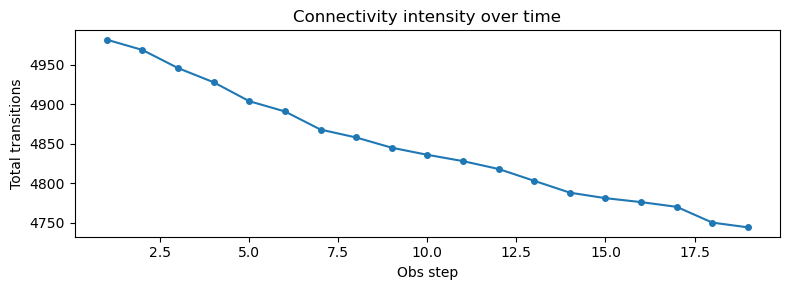

In [11]:
fig, ax = plt.subplots(figsize=(8, 3))
od_obs.groupby(level="obs_step").sum().plot(ax=ax, marker="o", ms=4)
ax.set_xlabel("Obs step")
ax.set_ylabel("Total transitions")
ax.set_title("Connectivity intensity over time")
plt.tight_layout()

## OD edges per obs step

One panel per transition step. Each panel shows the same weighted edge overlay
as the start-to-end plot, restricted to transitions occurring within that step.

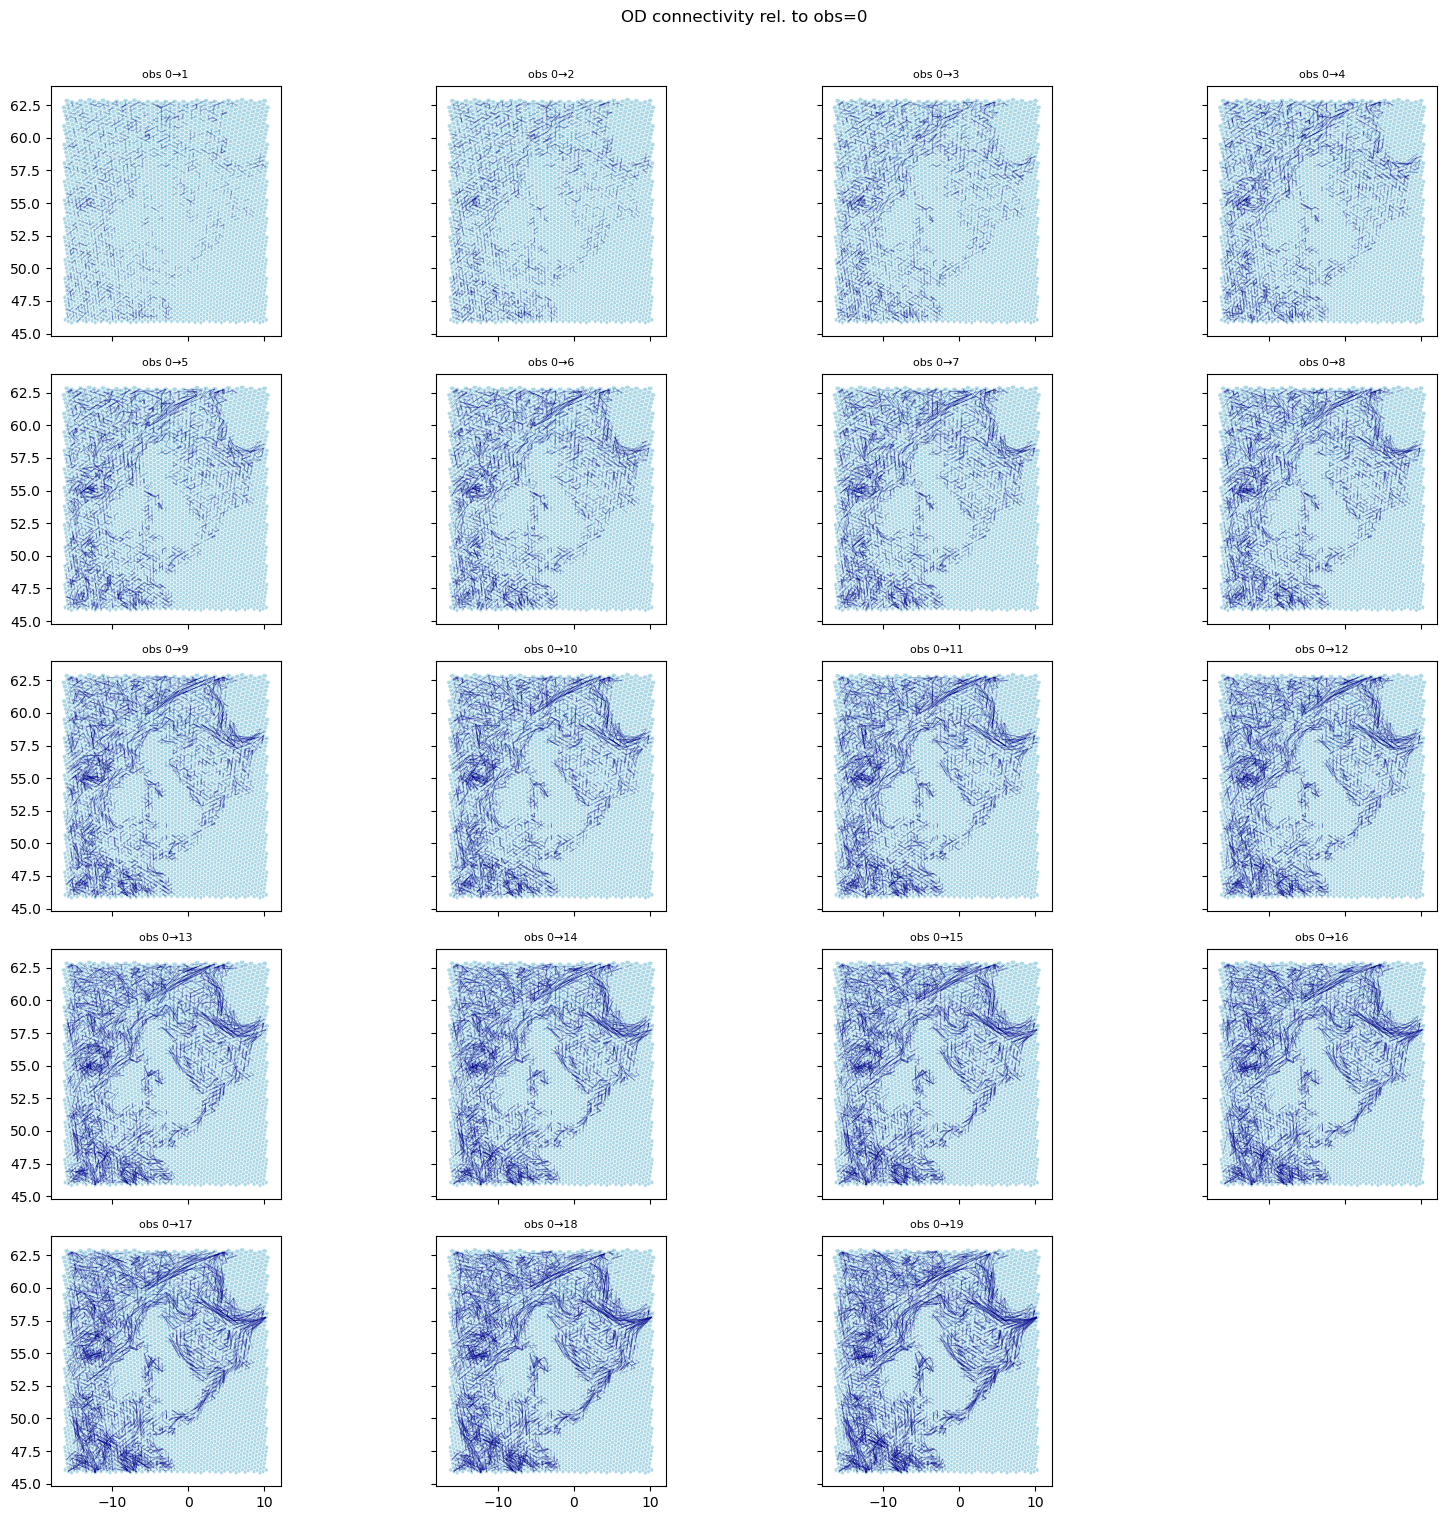

In [12]:
ncols = 4
nrows = (len(obs_steps) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), sharex=True, sharey=True)
axes_flat = axes.ravel()

for i, step in enumerate(obs_steps):
    ax = axes_flat[i]
    counts_step = od_obs.xs(step, level="obs_step")
    od_step = hp.edges_geodataframe(
        counts_step.index.get_level_values("from_id"),
        counts_step.index.get_level_values("to_id"),
        weight=counts_step.values,
    )
    region_gdf.plot(color="lightblue", edgecolor="white", linewidth=0.3, ax=ax)
    w = od_step["weight"]
    od_step.plot(
        ax=ax,
        linewidth=0.3 + 2.0 * (w - w.min()) / (w.max() - w.min() + 1),
        color="darkblue", alpha=0.5,
    )
    ax.set_title(f"obs 0→{step}", fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in axes_flat[len(obs_steps):]:
    ax.set_visible(False)

plt.suptitle("OD connectivity rel. to obs=0", y=1.01)
plt.tight_layout()